In [1]:
import kagglehub
import pandas as pd
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download("patelris/crop-yield-prediction-dataset")

print("Dataset path:", path)
print(os.listdir(path))

100%|██████████| 959k/959k [00:01<00:00, 643kB/s]

Extracting files...
Dataset path: C:\Users\USER\.cache\kagglehub\datasets\patelris\crop-yield-prediction-dataset\versions\1
['pesticides.csv', 'rainfall.csv', 'temp.csv', 'yield.csv', 'yield_df.csv']


In [3]:
data = pd.read_csv(os.path.join(path, "crop_yield.csv"))

data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\USER\\.cache\\kagglehub\\datasets\\patelris\\crop-yield-prediction-dataset\\versions\\1\\crop_yield.csv'

In [4]:
data = pd.read_csv(os.path.join(path, "yield_df.csv"))

data.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [5]:
print(data.shape)
print(data.columns)


(28242, 8)
Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')


In [6]:
data = data.drop("Unnamed: 0", axis=1)

In [7]:
data = data.rename(columns={"hg/ha_yield": "yield"})

In [8]:
print(data.columns)

Index(['Area', 'Item', 'Year', 'yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')


In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data["Area"] = encoder.fit_transform(data["Area"])
data["Item"] = encoder.fit_transform(data["Item"])

In [10]:
X = data.drop("yield", axis=1)
y = data["yield"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
print("Intercept:", model.intercept_)

print("Coefficients:", model.coef_)

Intercept: -1903137.3930509668
Coefficients: [ 9.06491303e+01 -7.68771108e+03  1.01973640e+03  3.37989847e+00
  1.00522189e-01 -1.88753039e+03]


In [14]:
import pandas as pd

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coeff_df)

                         Feature  Coefficient
0                           Area    90.649130
1                           Item -7687.711077
2                           Year  1019.736405
3  average_rain_fall_mm_per_year     3.379898
4              pesticides_tonnes     0.100522
5                       avg_temp -1887.530390


In [15]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))


NameError: name 'predictions' is not defined

In [16]:
predictions = model.predict(X_test)

In [17]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))


R2 Score: 0.08425172276039405
MAE: 62444.310629755855


In [18]:
print(len(y_test))
print(len(predictions))

5649
5649


In [19]:
print(type(predictions))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [20]:
import numpy as np

print("R2 Score:", r2_score(np.array(y_test), np.array(predictions)))
print("MAE:", mean_absolute_error(np.array(y_test), np.array(predictions)))

R2 Score: 0.08425172276039405
MAE: 62444.310629755855


In [21]:
predictions = model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))

R2 Score: 0.08425172276039405
MAE: 62444.310629755855


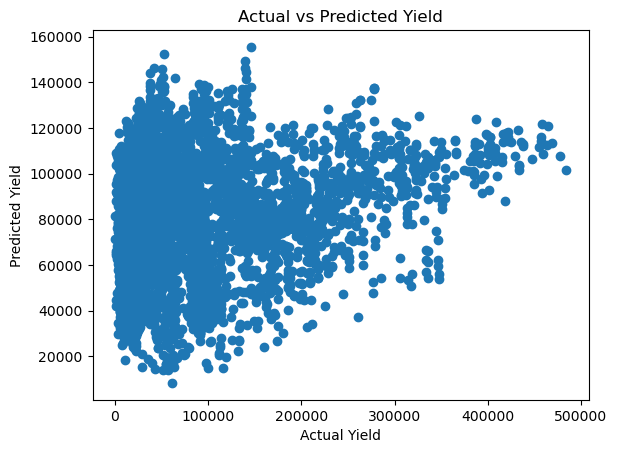

In [22]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.show()

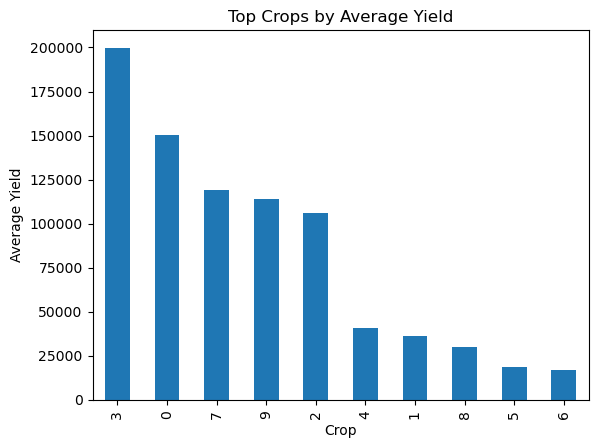

In [23]:
import matplotlib.pyplot as plt

crop_yield = data.groupby("Item")["yield"].mean().sort_values(ascending=False)

plt.figure()

crop_yield.head(10).plot(kind="bar")

plt.xlabel("Crop")
plt.ylabel("Average Yield")
plt.title("Top Crops by Average Yield")

plt.show()

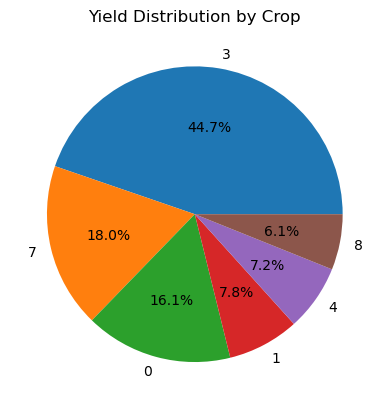

In [24]:
crop_share = data.groupby("Item")["yield"].sum().sort_values(ascending=False)

top_crops = crop_share.head(6)

plt.figure()

plt.pie(top_crops, labels=top_crops.index, autopct='%1.1f%%')

plt.title("Yield Distribution by Crop")

plt.show()

In [25]:
actual_df = pd.DataFrame({
    "Item": X_test["Item"],
    "Actual_Yield": y_test
})

pred_df = pd.DataFrame({
    "Item": X_test["Item"],
    "Predicted_Yield": predictions
})

In [26]:
actual_crop = actual_df.groupby("Item")["Actual_Yield"].sum()
pred_crop = pred_df.groupby("Item")["Predicted_Yield"].sum()
actual_crop = actual_crop.sort_values(ascending=False).head(6)
pred_crop = pred_crop.sort_values(ascending=False).head(6)

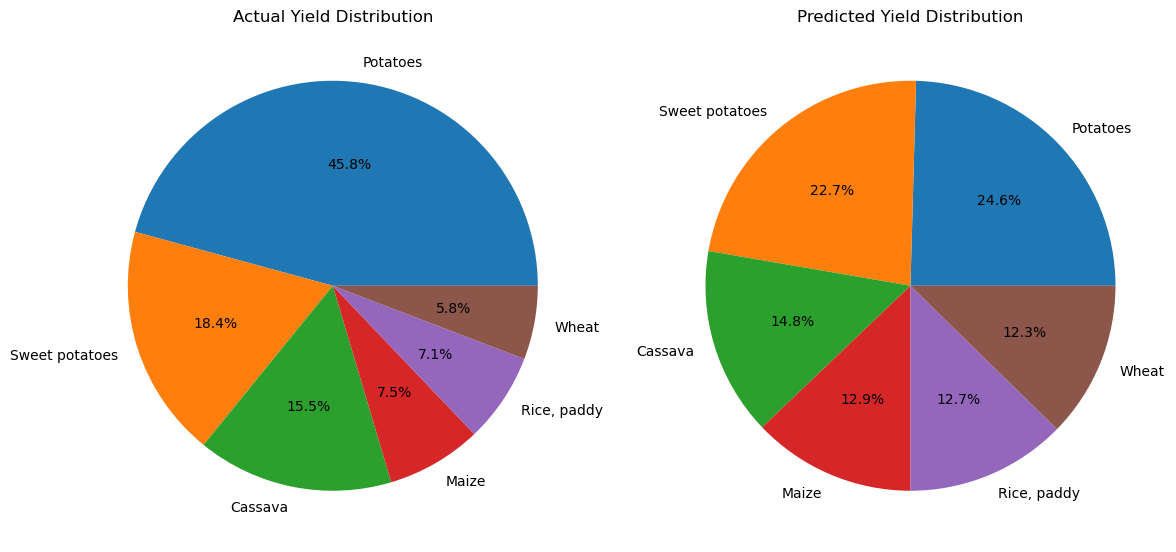

In [30]:
import matplotlib.pyplot as plt
import numpy as np



labels = encoder.inverse_transform(actual_crop.index)

fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].pie(actual_crop, labels=labels, autopct='%1.1f%%', colors=colors)
ax[0].set_title("Actual Yield Distribution")

ax[1].pie(pred_crop, labels=labels, autopct='%1.1f%%', colors=colors)
ax[1].set_title("Predicted Yield Distribution")

plt.tight_layout()
plt.show()

In [31]:
print(actual_crop.index)
print(pred_crop.index)

Index([3, 7, 0, 1, 4, 8], dtype='int64', name='Item')
Index([1, 3, 4, 6, 5, 0], dtype='int64', name='Item')


In [32]:
common_items = actual_crop.index.intersection(pred_crop.index)

In [33]:
actual_crop = actual_crop.loc[common_items]
pred_crop = pred_crop.loc[common_items]

In [34]:
print(actual_crop.index)
print(pred_crop.index)

Index([3, 0, 1, 4], dtype='int64', name='Item')
Index([3, 0, 1, 4], dtype='int64', name='Item')


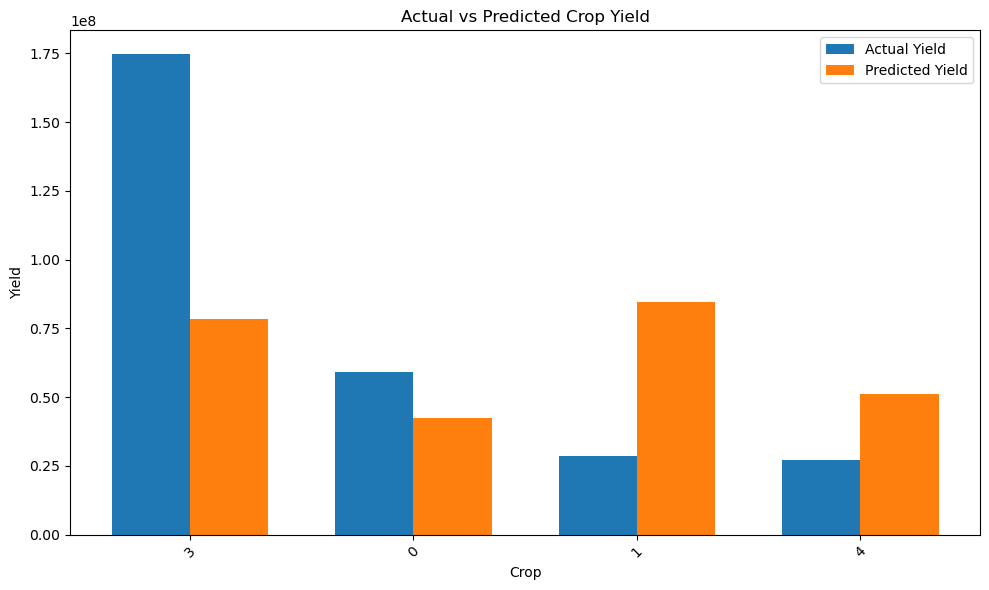

In [35]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(actual_crop))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, actual_crop, width, label="Actual Yield")
plt.bar(x + width/2, pred_crop, width, label="Predicted Yield")

plt.xticks(x, actual_crop.index, rotation=45)

plt.xlabel("Crop")
plt.ylabel("Yield")
plt.title("Actual vs Predicted Crop Yield")

plt.legend()

plt.tight_layout()
plt.show()